# 08. HAllA Exploration

This notebook runs HAllA as an exploratory metadata-microbiome block-association screen.
It is intentionally separated from the main inferential notebooks because HAllA does not explicitly model repeated measures.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import workflow_core as wc

context, base_data, base, advanced = wc.bootstrap_notebook()


## Define Notebook-Local HAllA Helpers

These helper functions are kept in this notebook because they are only used here.


In [2]:
import shutil

from rpy2.robjects import packages as rpackages


EMPTY_TOP_PAIRS = pd.DataFrame(
    columns=["X_features", "Y_features", "association", "p-values", "q-values"]
)
EMPTY_SIG_CLUSTERS = pd.DataFrame(
    columns=[
        "cluster_rank",
        "metadata_features",
        "microbiome_features",
        "best_adjusted_pvalue",
        "metadata_size",
        "microbiome_size",
    ]
)


class _MissingRPackage:
    def __init__(self, name):
        self.name = name

    def __getattr__(self, attr):
        raise RuntimeError(
            f'R package "{self.name}" is required for this HAllA code path but is not installed.'
        )


def patch_optional_r_imports():
    real_importr = rpackages.importr

    def patched_importr(name, *args, **kwargs):
        if name in {"XICOR", "eva"}:
            return _MissingRPackage(name)
        return real_importr(name, *args, **kwargs)

    rpackages.importr = patched_importr


def import_halla_class():
    try:
        from halla import HAllA
        return HAllA
    except Exception as primary_exc:
        fallback_site = Path("/home/ubuntu/miniforge3/lib/python3.12/site-packages")
        if fallback_site.exists() and str(fallback_site) not in sys.path:
            sys.path.append(str(fallback_site))
        # Clear any failed or shadowed module entry before retrying import.
        sys.modules.pop("halla", None)
        try:
            from halla import HAllA
            return HAllA
        except Exception as secondary_exc:
            raise ImportError(
                "Unable to import HAllA from current env or base Miniforge site-packages. "
                f"primary={primary_exc!r}; fallback={secondary_exc!r}"
            )


def prepare_halla_inputs():
    input_dir = context.halla_dir / "inputs"
    input_dir.mkdir(parents=True, exist_ok=True)

    qc = base_data["qc"]
    species_bac = base_data["species_bac"]

    sample_ids = qc.index[qc["model_qc_pass"]].tolist()
    rel_ab = species_bac.loc[sample_ids].copy()
    rel_ab = rel_ab.div(rel_ab.sum(axis=1), axis=0).fillna(0)
    prevalence = (rel_ab > 0).mean(axis=0)
    rel_ab = rel_ab.loc[:, prevalence >= 0.1]

    metadata = qc.loc[
        sample_ids,
        [
            "host_removed_fraction",
            "log10_bacterial_reads",
            "culture_s_aureus",
            "culture_p_aeruginosa",
            "culture_serratia_marcescens",
            "culture_proteus_mirabilis",
            "culture_gas",
            "culture_klebsiella_spp",
            "culture_e_coli",
            "culture_acinetobacter_baumannii",
            "culture_e_faecalis",
            "body_region",
            "chronicity_group",
            "clinical_infection_flag",
        ],
    ].copy()
    metadata = pd.get_dummies(
        metadata,
        columns=["body_region", "chronicity_group", "clinical_infection_flag"],
        dtype=float,
    )
    metadata = metadata.replace({True: 1.0, False: 0.0})
    metadata = metadata.apply(pd.to_numeric, errors="raise").astype(float)

    metadata_t = metadata.transpose()
    metadata_t.index.name = "feature"
    metadata_path = input_dir / "metadata_features_by_samples.tsv"
    metadata_t.to_csv(metadata_path, sep="\t")

    microbiome_t = rel_ab.transpose()
    microbiome_t.index.name = "feature"
    microbiome_path = input_dir / "microbiome_features_by_samples.tsv"
    microbiome_t.to_csv(microbiome_path, sep="\t")
    return metadata_path, microbiome_path


def summarize_halla_results(output_dir):
    all_assoc = pd.read_csv(output_dir / "all_associations.txt", sep="\t")
    sig_clusters = pd.read_csv(output_dir / "sig_clusters.txt", sep="\t")

    top_pairs = (
        all_assoc.assign(abs_association=lambda df: df["association"].abs())
        .sort_values(["q-values", "abs_association"], ascending=[True, False])
        .drop(columns=["abs_association"])
        .head(100)
        .reset_index(drop=True)
    )

    sig_clusters = sig_clusters.rename(
        columns={
            "cluster_X": "metadata_features",
            "cluster_Y": "microbiome_features",
            "best_adjusted_pvalue": "best_adjusted_pvalue",
        }
    )
    sig_clusters["metadata_size"] = sig_clusters["metadata_features"].str.count(";").fillna(0).astype(int) + 1
    sig_clusters["microbiome_size"] = sig_clusters["microbiome_features"].str.count(";").fillna(0).astype(int) + 1
    return top_pairs, sig_clusters


## Run HAllA And Save Numbered Outputs


Setting config parameters (irrelevant parameters will be ignored)...
  preprocess:
    max freq thresh               : 1
    transform funcs               : None
    discretize bypass if possible : True
    discretize func               : None
    discretize num bins           : None
  association:
    pdist metric                  : spearman
  hierarchy:
    sim2dist set abs              : True
    sim2dist func                 : None
    linkage method                : average
  permute:
    iters                         : 1000
    func                          : gpd
    speedup                       : True
  stats:
    fdr alpha                     : 0.05
    fdr method                    : fdr_bh
    fnr thresh                    : 0.2
    rank cluster                  : best
  output:
    dir                           : /home/ubuntu/dev/20250320_eb_summary/metagenomics_20260206/analysis_update/halla_output/output
    verbose                       : True

== Loading and preprocessi

Generating the p-value table...
The first p-value computation took about 0.0 seconds. Extrapolating from this, computing the entire p-value table should take roughly 22.686 seconds...


  0%|          | 0/23 [00:00<?, ?it/s]

  4%|▍         | 1/23 [00:00<00:04,  5.19it/s]

  9%|▊         | 2/23 [00:00<00:04,  5.21it/s]

...

100%|██████████| 23/23 [00:04<00:00,  4.95it/s]


Generating the q-value table...
*  Number of significant associations 1500
-- Completed; total duration: 0:00:08.995790 --

-- Step 2: Performing hierarchical clustering --


-- Completed; total duration: 0:00:57.633176 --

-- Step 3: Finding densely associated blocks --


*  Number of significant clusters 436
-- Completed; total duration: 0:00:00.473217 --

== Generating reports ==
Directory /home/ubuntu/dev/20250320_eb_summary/metagenomics_20260206/analysis_update/halla_output/output exists; deleting...
Creating a new directory /home/ubuntu/dev/20250320_eb_summary/metagenomics_20260206/analysis_update/halla_output/output


PosixPath('/home/ubuntu/dev/20250320_eb_summary/metagenomics_20260206/analysis_update/tables/table_08_03_halla_significant_clusters.tsv')

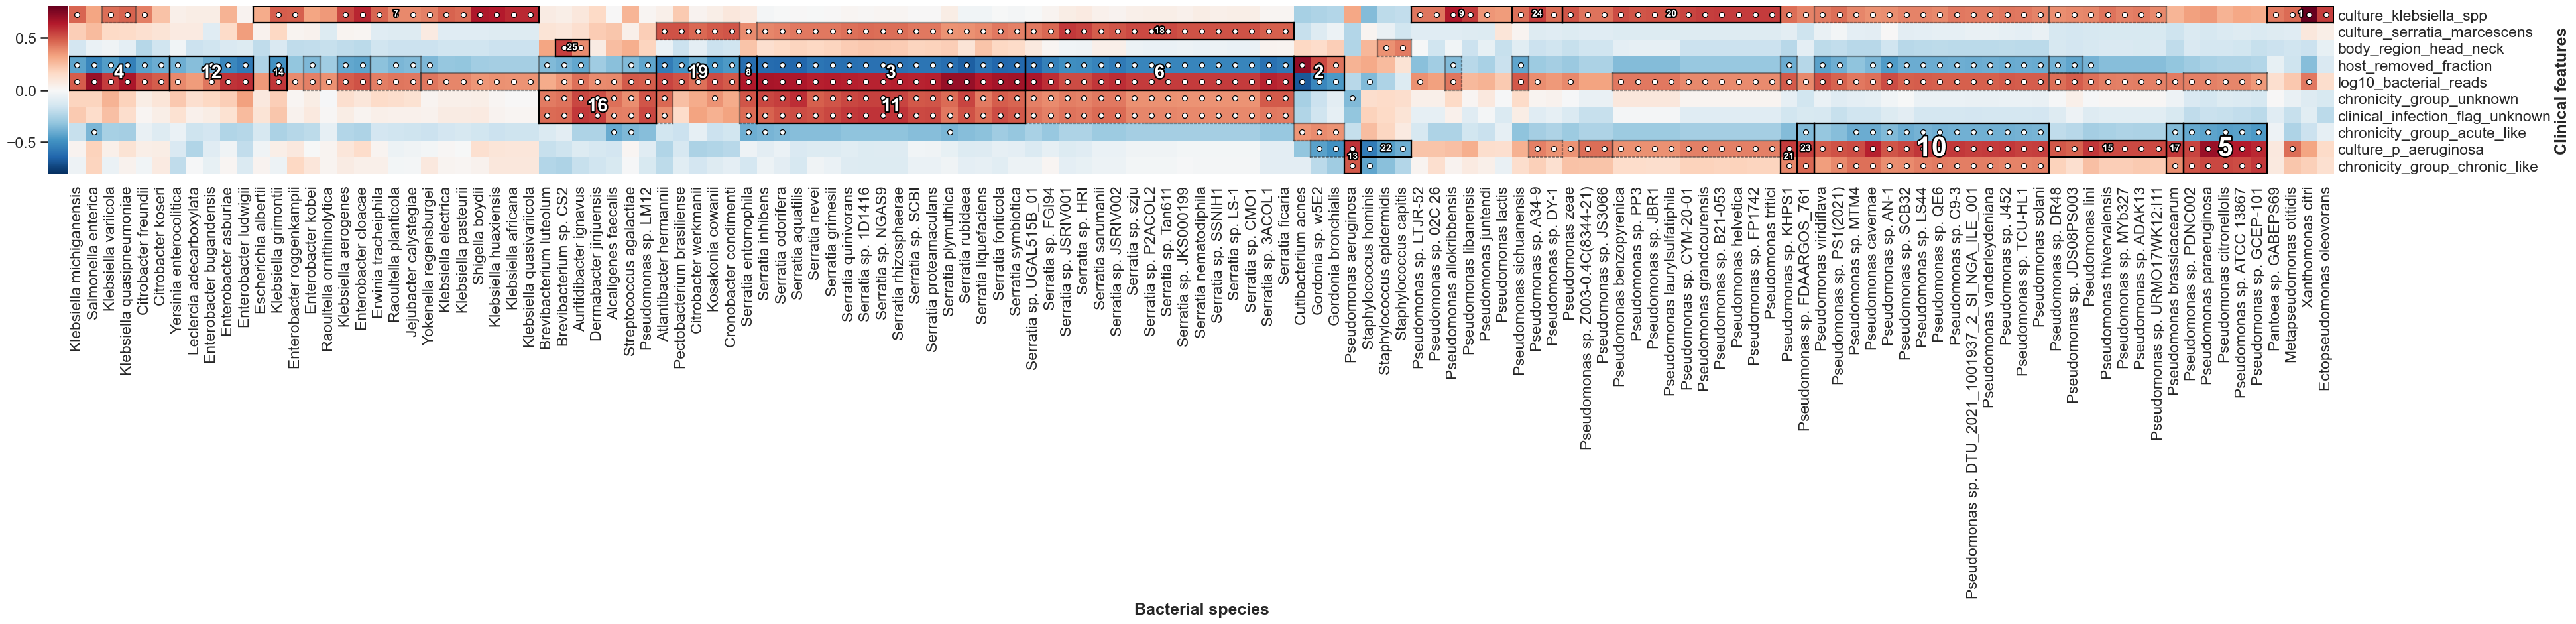

In [3]:
patch_optional_r_imports()
metadata_path, microbiome_path = prepare_halla_inputs()
figure_file = wc.figure_path(context, 8, "halla_top25")
if figure_file.exists():
    figure_file.unlink()

output_dir = context.halla_dir / "output"
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

rows = []
top_pairs = EMPTY_TOP_PAIRS.copy()
sig_clusters = EMPTY_SIG_CLUSTERS.copy()

try:
    HAllA = import_halla_class()

    halla = HAllA(
        pdist_metric="spearman",
        out_dir=str(output_dir),
        verbose=True,
        num_threads=1,
        force_permutations=False,
    )
    halla.load(str(metadata_path), str(microbiome_path))
    halla.run()
    halla.generate_hallagram(
        block_num=25,
        x_dataset_label="Clinical features",
        y_dataset_label="Bacterial species",
        output_file="hallagram_top25",
        plot_type="svg",
    )
    top_pairs, sig_clusters = summarize_halla_results(output_dir)
    rows.append(
        {
            "method": "HAllA",
            "status": "ran_with_local_shim",
            "runnable": True,
            "reason": "Executed in spearman mode with optional R-package imports shimmed locally.",
            "detail": "Optional HAllA startup imports for XICOR/eva were shimmed so the non-xicor, non-permutation workflow could run.",
        }
    )
except Exception as exc:
    rows.append(
        {
            "method": "HAllA",
            "status": "failed",
            "runnable": False,
            "reason": "Execution failed in the local environment.",
            "detail": repr(exc),
        }
    )

method_status = pd.DataFrame(rows)
hallagram = output_dir / "hallagram_top25.svg"
if hallagram.exists():
    shutil.copy2(hallagram, figure_file)

wc.save_table(method_status, wc.table_path(context, 20, "halla_method_status"))
wc.save_table(top_pairs, wc.table_path(context, 21, "halla_top_pairwise_associations"))
wc.save_table(sig_clusters, wc.table_path(context, 22, "halla_significant_clusters"))


## Review Numbered Outputs


,method,status,runnable,reason,detail
0,HAllA,ran_with_local_shim,True,Executed in spearman mode with optional R-pack...,Optional HAllA startup imports for XICOR/eva w...


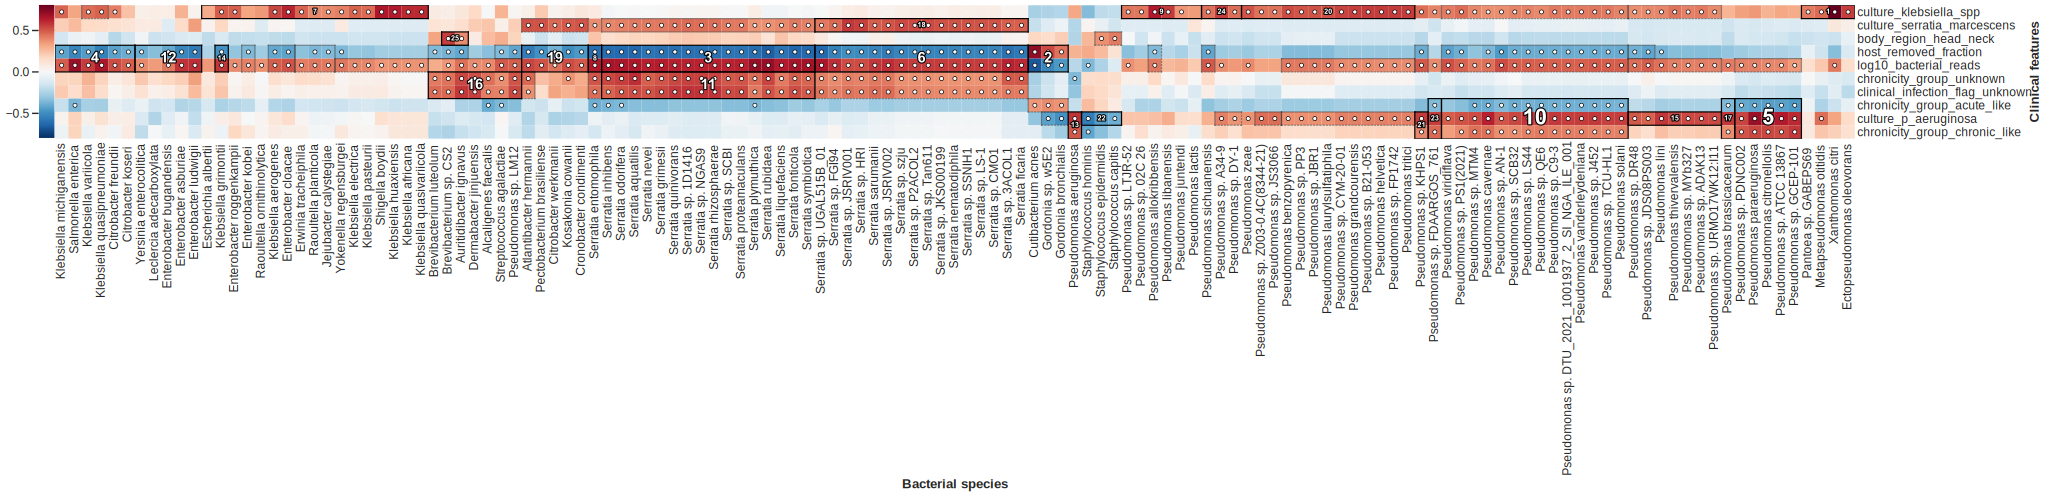

,X_features,Y_features,association,p-values,q-values
0,culture_klebsiella_spp,Xanthomonas citri,0.804224,5.928874e-15,8.045482e-11
1,host_removed_fraction,Cutibacterium acnes,0.710297,1.444541e-10,9.801208e-07
2,log10_bacterial_reads,Serratia plymuthica,0.703238,2.625730e-10,1.061882e-06
3,log10_bacterial_reads,Serratia rubidaea,0.701122,3.130086e-10,1.061882e-06
4,culture_p_aeruginosa,Pseudomonas paraeruginosa,0.691932,6.599979e-10,1.574621e-06
5,log10_bacterial_reads,Salmonella enterica,0.691260,6.962217e-10,1.574621e-06
6,log10_bacterial_reads,Cutibacterium acnes,-0.681104,1.535531e-09,2.976736e-06
7,log10_bacterial_reads,Serratia symbiotica,0.673637,2.692910e-09,4.164985e-06
8,culture_p_aeruginosa,Pseudomonas citronellolis,0.673294,2.762333e-09,4.164985e-06
9,log10_bacterial_reads,Serratia fonticola,0.667140,4.333710e-09,5.880845e-06


,cluster_rank,metadata_features,microbiome_features,best_adjusted_pvalue,metadata_size,microbiome_size
0,1,culture_klebsiella_spp,Pantoea sp. GABEPS69;Metapseudomonas otitidis;...,8.045482e-11,1,4
1,2,host_removed_fraction;log10_bacterial_reads,Cutibacterium acnes;Gordonia sp. w5E2;Gordonia...,9.801208e-07,2,3
2,3,host_removed_fraction;log10_bacterial_reads,Serratia inhibens;Serratia odorifera;Serratia ...,1.061882e-06,2,16
3,4,host_removed_fraction;log10_bacterial_reads,Klebsiella michiganensis;Salmonella enterica;K...,1.574621e-06,2,6
4,5,chronicity_group_acute_like;culture_p_aerugino...,Pseudomonas sp. PDNC002;Pseudomonas paraerugin...,1.574621e-06,3,5
5,6,host_removed_fraction;log10_bacterial_reads,Serratia sp. UGAL515B_01;Serratia sp. FGI94;Se...,9.645942e-06,2,16
6,7,culture_klebsiella_spp,Escherichia albertii;Klebsiella grimontii;Ente...,9.859919e-06,1,17
7,8,host_removed_fraction;log10_bacterial_reads,Serratia entomophila,1.626175e-05,2,1
8,9,culture_klebsiella_spp,Pseudomonas sp. LTJR-52;Pseudomonas sp. 02C 26...,1.890966e-05,1,6
9,10,chronicity_group_acute_like;culture_p_aerugino...,Pseudomonas viridiflava;Pseudomonas sp. PS1(20...,3.346375e-05,3,14


## Working Interpretation
- HAllA status: ran_with_local_shim.
- Positive result: HAllA provides an exploratory block-level view of metadata-microbiome associations.
- Negative result: it is not the primary inferential layer here because it does not model patient and culture-date batch structure the way the mixed models do.

In [4]:
method_status = pd.read_csv(wc.table_path(context, 20, "halla_method_status"), sep="\t")
top_pairs = pd.read_csv(wc.table_path(context, 21, "halla_top_pairwise_associations"), sep="\t")
sig_clusters = pd.read_csv(wc.table_path(context, 22, "halla_significant_clusters"), sep="\t")

display(method_status)
figure_file = wc.figure_path(context, 8, "halla_top25")
if figure_file.exists():
    display(SVG(filename=str(figure_file)))
display(top_pairs.head(20))
display(sig_clusters.head(20))

status = method_status.iloc[0]["status"]
summary_lines = [
    f"- HAllA status: {status}.",
    "- Positive result: HAllA provides an exploratory block-level view of metadata-microbiome associations.",
    "- Negative result: it is not the primary inferential layer here because it does not model patient and culture-date batch structure the way the mixed models do.",
]
display(Markdown("## Working Interpretation\n" + "\n".join(summary_lines)))
